# 1. Necessary

In [1]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use('ggplot')

start_date = "2019-01-01"
end_date = "2024-01-01"

#functions
from src.portfolio_stats import calculate_volatility, calculate_max_drawdown, calculate_mean_portfolio_returns, calculate_sharpe_ratio, calculate_cagr, calculate_return_path
from src.optimizations import calculate_negative_sharpe_ratio

#data
data = pd.read_csv("data/prices.csv", index_col="Date", parse_dates=True)

from data_loader import read_rfr
rfr = read_rfr(start_date, end_date)


#checking data
print(rfr)
print(data.head())

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

0.022721041324881567
                 AAPL        BND        EEM         GLD        JPM  \
Date                                                                 
2019-01-02  37.503731  64.321190  33.319092  121.330002  81.250214   
2019-01-03  33.768089  64.572426  32.714989  122.430000  80.095505   
2019-01-04  35.209606  64.377945  33.770042  121.440002  83.048248   
2019-01-07  35.131241  64.280693  33.846607  121.860001  83.105980   
2019-01-08  35.800953  64.199631  33.974236  121.529999  82.949287   

                   SPY        TSM        XOM  
Date                                          
2019-01-02  224.995300  31.237255  50.001854  
2019-01-03  219.626328  29.389702  49.234116  
2019-01-04  226.982864  29.911467  51.049370  
2019-01-07  228.772537  30.133848  51.314850  
2019-01-08  230.921951  29.885805  51.687931  


# 2. Stress Test (out of sample)

## 2.1. Creating Train-Fitted Tangency Portfolio

In [2]:
#training on 3 years, then checking performance on latter 2.

In [3]:
#defining train vs test data

train_start_date = '2019-01-03'
train_end_date = '2021-12-31'
test_start_date = '2022-01-01'
test_end_date = '2023-12-31'

train_data = data.loc[train_start_date : train_end_date]
test_data = data.loc[test_start_date : test_end_date]

In [4]:
train_data

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,33.768089,64.572426,32.714989,122.430000,80.095505,219.626328,29.389702,49.234116
2019-01-04,35.209606,64.377945,33.770042,121.440002,83.048248,226.982864,29.911467,51.049370
2019-01-07,35.131241,64.280693,33.846607,121.860001,83.105980,228.772537,30.133848,51.314850
2019-01-08,35.800953,64.199631,33.974236,121.529999,82.949287,230.921951,29.885805,51.687931
2019-01-09,36.408916,64.288780,34.578342,122.309998,82.809059,232.001114,30.458879,51.960587
...,...,...,...,...,...,...,...,...
2021-12-27,176.459732,73.956093,44.365376,169.369995,141.756668,451.449463,114.628281,53.338230
2021-12-28,175.442032,73.947380,44.220333,168.639999,142.186890,451.080627,114.030373,53.165867
2021-12-29,175.530121,73.703384,44.020893,168.589996,142.115189,451.657623,113.423149,52.700478


In [5]:
equal_weights = np.array([1 / data.columns.size] * data.columns.size)
init_guess = equal_weights

In [6]:
rfr

0.022721041324881567

In [7]:
#fitting tangency portfolio on train data

rfr = read_rfr(train_start_date, train_end_date)
print('RFR Train:',rfr)

constraints_train = ({
    'type':'eq',
    'fun':lambda weights: np.sum(weights) - 1
    })

n = len(train_data.columns)
bounds_train = [(0,1)] * n

tangency_portfolio_train = minimize(calculate_negative_sharpe_ratio, init_guess, args=(train_data,), constraints=constraints_train, bounds=bounds_train)

[*********************100%***********************]  1 of 1 completed

RFR Train: 0.014843827791561355


Text(0.5, 1.0, 'Tangency Portfolio Weights (Stress Test)')

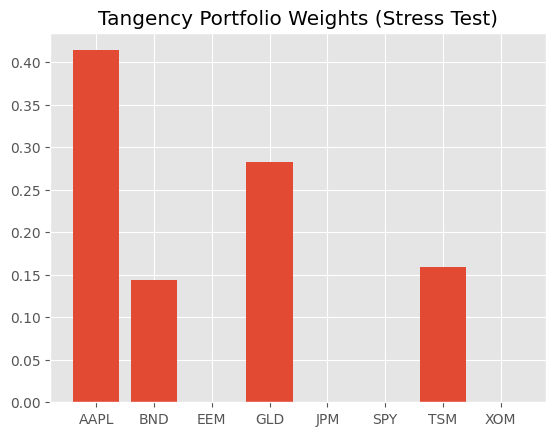

In [8]:
#train-fitted tangency aaportfolio weights

plt.bar(train_data.columns, tangency_portfolio_train.x)
plt.title('Tangency Portfolio Weights (Stress Test)')

## 2.2. Comparing Train VS Test Performance

In [9]:
#reporting train performance:
print('Train Data Performance:')
tangency_port_train_volatility = calculate_volatility(tangency_portfolio_train.x, train_data)
tangency_port_train_mean_return = calculate_mean_portfolio_returns(tangency_portfolio_train.x, train_data)
tangency_port_train_cagr = calculate_cagr(tangency_portfolio_train.x, train_data)
tangency_port_train_sharpe = calculate_sharpe_ratio(tangency_portfolio_train.x, train_data)

print('Train Tangency Portfolio Volatility:', tangency_port_train_volatility)
print('Train Tangency Portfolio Mean Returns:', tangency_port_train_mean_return)
print('Train Tangency Portfolio CAGR:', tangency_port_train_cagr)
print('Train Tangency Portfolio Sharpe Ratio:',tangency_port_train_sharpe)

#comparing to test performance:
print('Test Data Performance:')
tangency_port_test_volatility = calculate_volatility(tangency_portfolio_train.x, test_data)
tangency_port_test_mean_return = calculate_mean_portfolio_returns(tangency_portfolio_train.x, test_data)
tangency_port_test_cagr = calculate_cagr(tangency_portfolio_train.x, test_data)
tangency_port_test_sharpe = calculate_sharpe_ratio(tangency_portfolio_train.x, test_data)

print('Test Tangency Portfolio Volatility:', tangency_port_test_volatility)
print('Test Tangency Portfolio Mean Returns:', tangency_port_test_mean_return)
print('Test Tangency Portfolio CAGR:', tangency_port_test_cagr)
print('Test Tangency Portfolio Sharpe Ratio:',tangency_port_test_sharpe)

Train Data Performance:
Train Tangency Portfolio Volatility: 0.1888153030086098
Train Tangency Portfolio Mean Returns: 0.3730433741475175
Train Tangency Portfolio CAGR: 0.42545694169790105
Train Tangency Portfolio Sharpe Ratio: 1.8553704453005144
Test Data Performance:
Test Tangency Portfolio Volatility: 0.17238071841036787
Test Tangency Portfolio Mean Returns: 0.04329771535404135
Test Tangency Portfolio CAGR: 0.0288468280027665
Test Tangency Portfolio Sharpe Ratio: 0.11936760804172515


## 2.3. In-Sample VS Out-of-Sample Performance

In [10]:
#plotting the return paths throughout the test and train period for the portfolio
stress_test_return_path = calculate_return_path(tangency_portfolio_train.x, data)

#converting into series for earlier plotting
stress_test_return_path = pd.Series(stress_test_return_path, index=data.index)
stress_test_return_path.dropna()

Date
2019-01-03    0.952432
2019-01-04    0.969381
2019-01-07    0.970374
2019-01-08    0.975843
2019-01-09    0.987656
                ...   
2023-12-22    2.964478
2023-12-26    2.973739
2023-12-27    2.981834
2023-12-28    2.978868
2023-12-29    2.966692
Length: 1257, dtype: float64

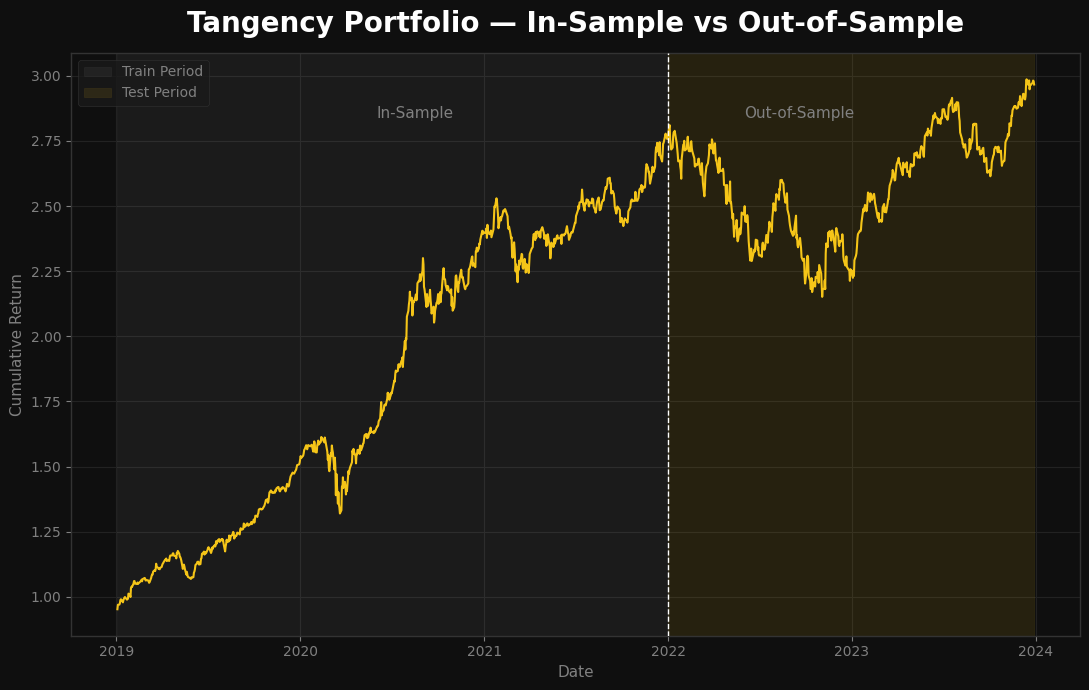

In [11]:
#return path across 5 years with the weights fitted on the first three.

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

# plot the return path
ax.plot(stress_test_return_path.index, stress_test_return_path.values,
        color='#f5c518', linewidth=1.5, zorder=2)

# vertical line separating train and test
split_date = '2022-01-01'
ax.axvline(x=pd.Timestamp(split_date), color='white', linewidth=1, linestyle='--', zorder=3)

# shade the two regions
ax.axvspan(stress_test_return_path.index[0], pd.Timestamp(split_date),
           alpha=0.05, color='white', label='Train Period')
ax.axvspan(pd.Timestamp(split_date), stress_test_return_path.index[-1],
           alpha=0.1, color='#f5c518', label='Test Period')

# label the two regions
ax.text(pd.Timestamp('2020-06-01'), stress_test_return_path.max() * 0.95,
        'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), stress_test_return_path.max() * 0.95,
        'Out-of-Sample', color='grey', fontsize=11)

# formatting
ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio — In-Sample vs Out-of-Sample', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

## 2.4. Tangency Portfolio VS SPY - Full Period

In [12]:
#comparing portfolio returns on test data with spy returns in the same period:

# isolate test period
test_start = '2022-01-01'
portfolio_test = stress_test_return_path[test_start:]

# spy return path over same period
spy_weights = np.array([1.0 if c == 'SPY' else 0.0 for c in data.columns])
spy_return_path = pd.Series(calculate_return_path(spy_weights, data), index=data.index)
spy_test = spy_return_path[test_start:]

# normalize both to start at 1 on the first day of test period
portfolio_test = portfolio_test / portfolio_test.iloc[0]
spy_test = spy_test / spy_test.iloc[0]

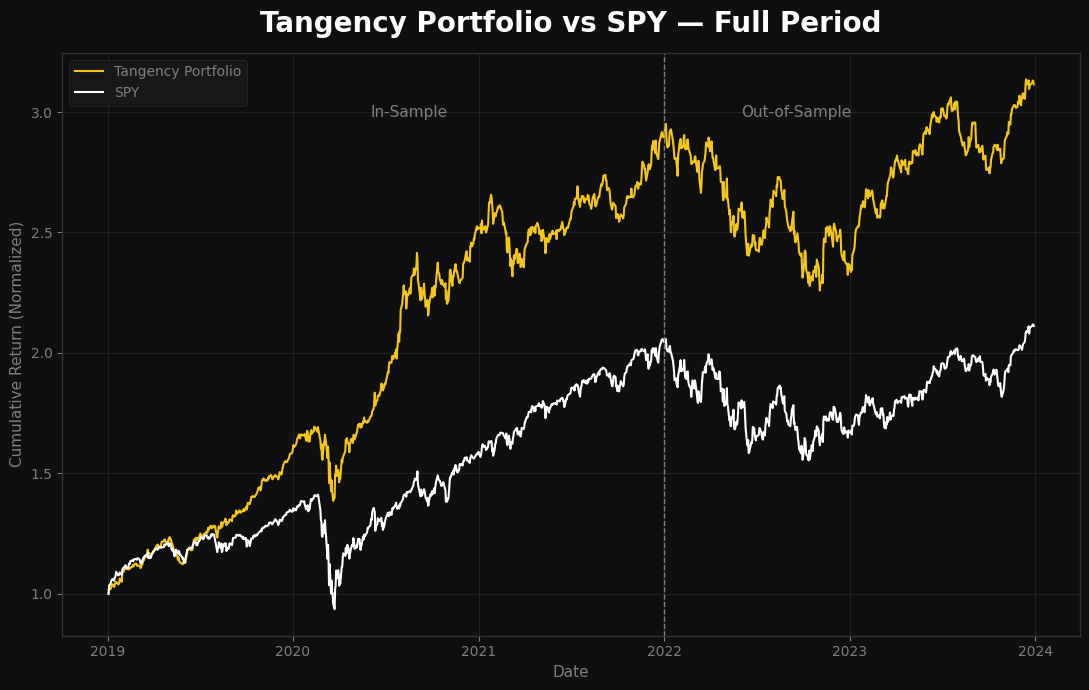

In [13]:
# normalize both to start at 1 on the first day
portfolio_full = stress_test_return_path.dropna() / stress_test_return_path.dropna().iloc[0]
spy_full = spy_return_path.dropna() / spy_return_path.dropna().iloc[0]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_full.index, portfolio_full.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(spy_full.index, spy_full.values, color='white', linewidth=1.5, label='SPY')

# train/test split line
ax.axvline(x=pd.Timestamp('2022-01-01'), color='grey', linewidth=1, linestyle='--')
ax.text(pd.Timestamp('2020-06-01'), portfolio_full.max() * 0.95, 'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), portfolio_full.max() * 0.95, 'Out-of-Sample', color='grey', fontsize=11)

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs SPY — Full Period', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

## 2.5. Tangency Portfolio VS SPY - Out-of-Sample

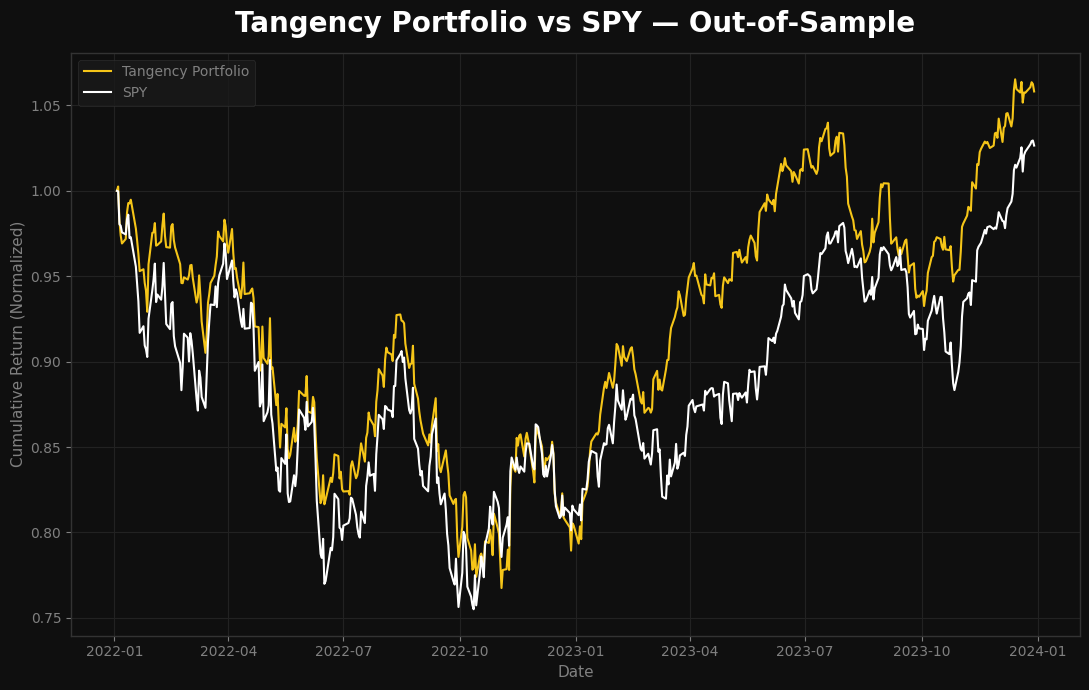

In [14]:

# plot
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_test.index, portfolio_test.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(spy_test.index, spy_test.values, color='white', linewidth=1.5, label='SPY')

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs SPY — Out-of-Sample', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
# conclusion: the dominance of the optimal portfolio over the
# benchmark SPY basically vanished in the out-of-sample period, suggesting overfitting.

### the poorer performance in the test period could be due to a broader worse period in the market however. for an accurate assesment, we must compare to an equal weight portfolio baseline.


In [16]:
stress_test_return_path

Date
2019-01-02         NaN
2019-01-03    0.952432
2019-01-04    0.969381
2019-01-07    0.970374
2019-01-08    0.975843
                ...   
2023-12-22    2.964478
2023-12-26    2.973739
2023-12-27    2.981834
2023-12-28    2.978868
2023-12-29    2.966692
Length: 1258, dtype: float64

In [17]:
eq_return_path = calculate_return_path(equal_weights, data)

## 2.6. Tangency Portfolio VS Equal Weight Portfolio - Full Period

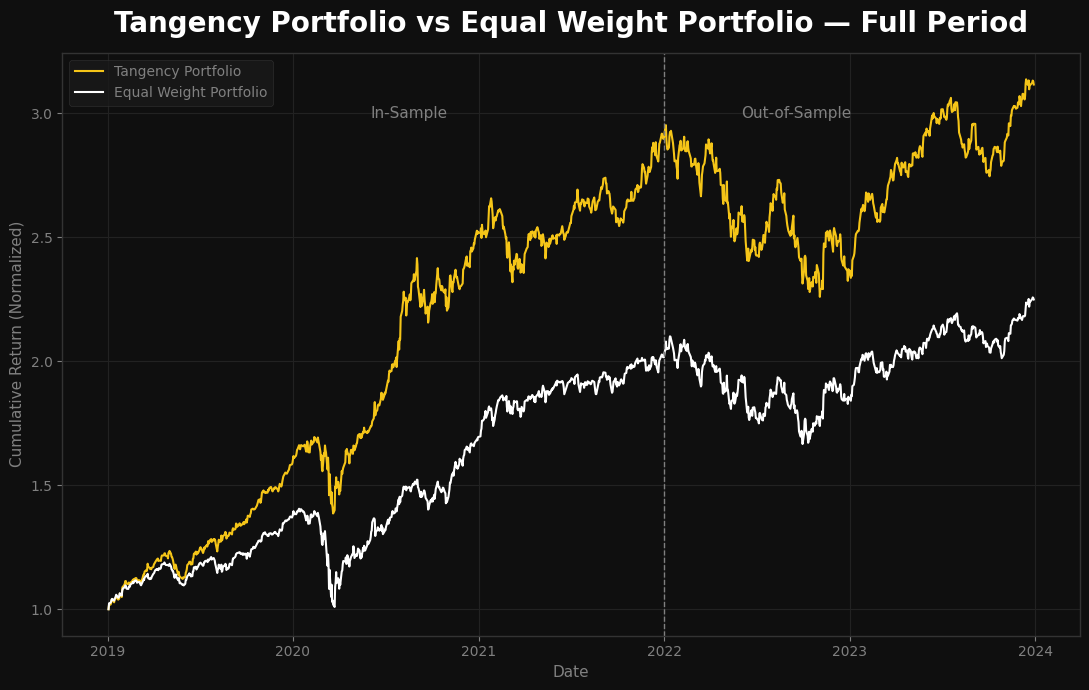

In [18]:
# normalize both to start at 1 on the first day
portfolio_full = stress_test_return_path.dropna() / stress_test_return_path.dropna().iloc[0]
eq_return_path = pd.Series(eq_return_path, stress_test_return_path.index)
eq_full = eq_return_path.dropna() / eq_return_path.dropna().iloc[0]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_full.index, portfolio_full.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(eq_full.index, eq_full.values, color='white', linewidth=1.5, label='Equal Weight Portfolio')

# train/test split line
ax.axvline(x=pd.Timestamp('2022-01-01'), color='grey', linewidth=1, linestyle='--')
ax.text(pd.Timestamp('2020-06-01'), portfolio_full.max() * 0.95, 'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), portfolio_full.max() * 0.95, 'Out-of-Sample', color='grey', fontsize=11)

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs Equal Weight Portfolio — Full Period', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

## 2.7. Tangency Portfolio VS Equal Weight Portfolio - Full Period

In [19]:
#calculating out of sample return of both:
oos_start = '2022-01-01'

portfolio_oos = portfolio_full[portfolio_full.index >= oos_start]
eq_oos = eq_full[eq_full.index >= oos_start]

tangency_total_return = (portfolio_oos.iloc[-1] / portfolio_oos.iloc[0] - 1) * 100
eq_total_return = (eq_oos.iloc[-1] / eq_oos.iloc[0] - 1) * 100

print(f"Tangency Portfolio OOS Total Return: {tangency_total_return:.2f}%")
print(f"Equal Weight Portfolio OOS Total Return: {eq_total_return:.2f}%")

Tangency Portfolio OOS Total Return: 5.82%
Equal Weight Portfolio OOS Total Return: 9.54%


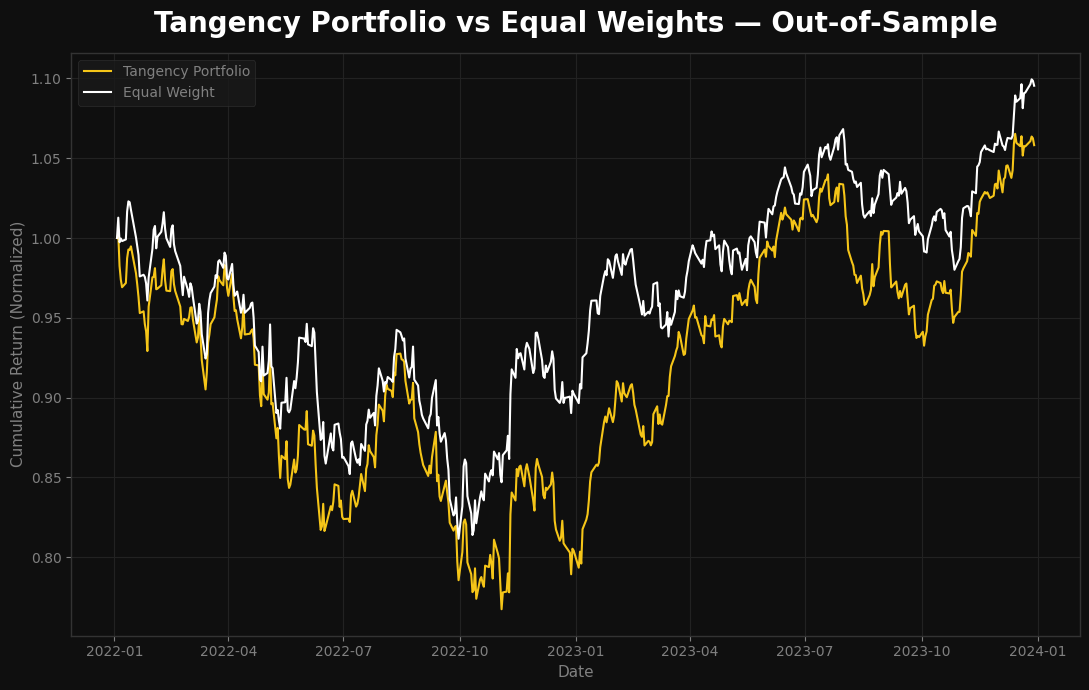

In [20]:
#comparing portfolio returns on test data with spy returns in the same period:

# isolate test period
test_start = '2022-01-01'
portfolio_test = stress_test_return_path[test_start:]

# spy return path over same period
equal_weights = np.ones(len(data.columns)) / len(data.columns)
eq_return_path = pd.Series(calculate_return_path(equal_weights, data), index=data.index)
eq_test = eq_return_path[test_start:]

# normalize both to start at 1 on the first day of test period
portfolio_test = portfolio_test / portfolio_test.iloc[0]
eq_test = eq_test / eq_test.iloc[0]

# plot
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_test.index, portfolio_test.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(eq_test.index, eq_test.values, color='white', linewidth=1.5, label='Equal Weight')

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs Equal Weights — Out-of-Sample', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [21]:
#this suggests large overfitting. the model doesn't seem to generalize to new data, rendering this approach largely useless.